In [66]:
import warnings
warnings.filterwarnings("ignore")

# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import zscore

# Data Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [67]:
df=pd.read_csv("data/raw.csv")

In [68]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [69]:
df["Churn"]=df["Churn"].replace({"Yes":1,"No":0})

In [70]:
X = df.drop(columns=['customerID',"PhoneService","Churn"],axis=1)
y = df['Churn']

In [71]:
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

In [72]:
le=LabelEncoder()
for i in cat_features:
    X[i]=le.fit_transform(X[i])

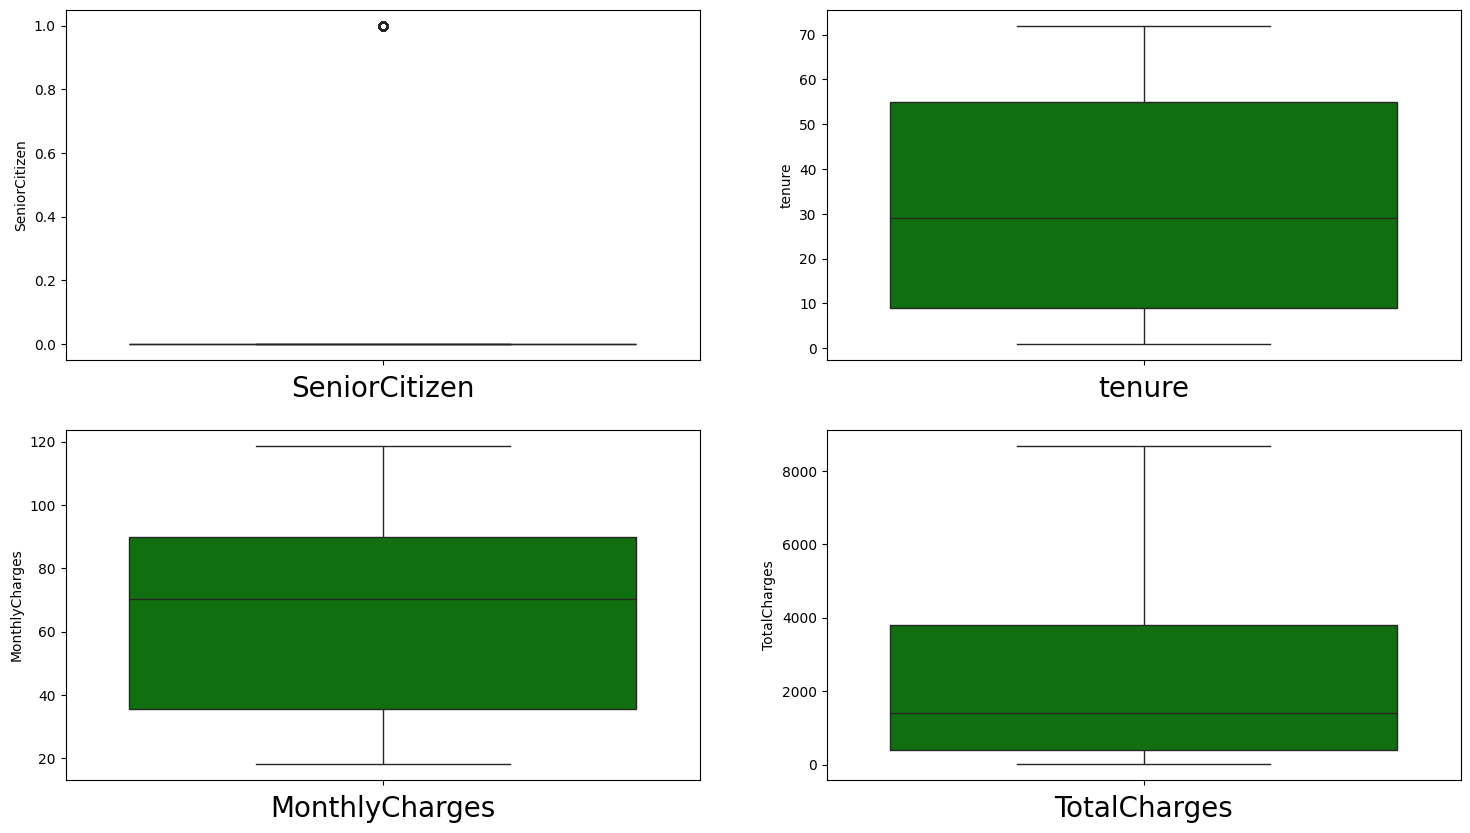

In [73]:
plt.figure(figsize=(18,10),facecolor="white")
plotnumber=1

for column in num_features:
    if plotnumber:
        ax=plt.subplot(2,2,plotnumber)
        sns.boxplot(X[column],color="g")
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [74]:
z=np.abs(zscore(X))
df1=X[(z<3).all(axis=1)]
print(df1.shape)
print(X.shape)
X=df1.copy()

(7032, 18)
(7032, 18)


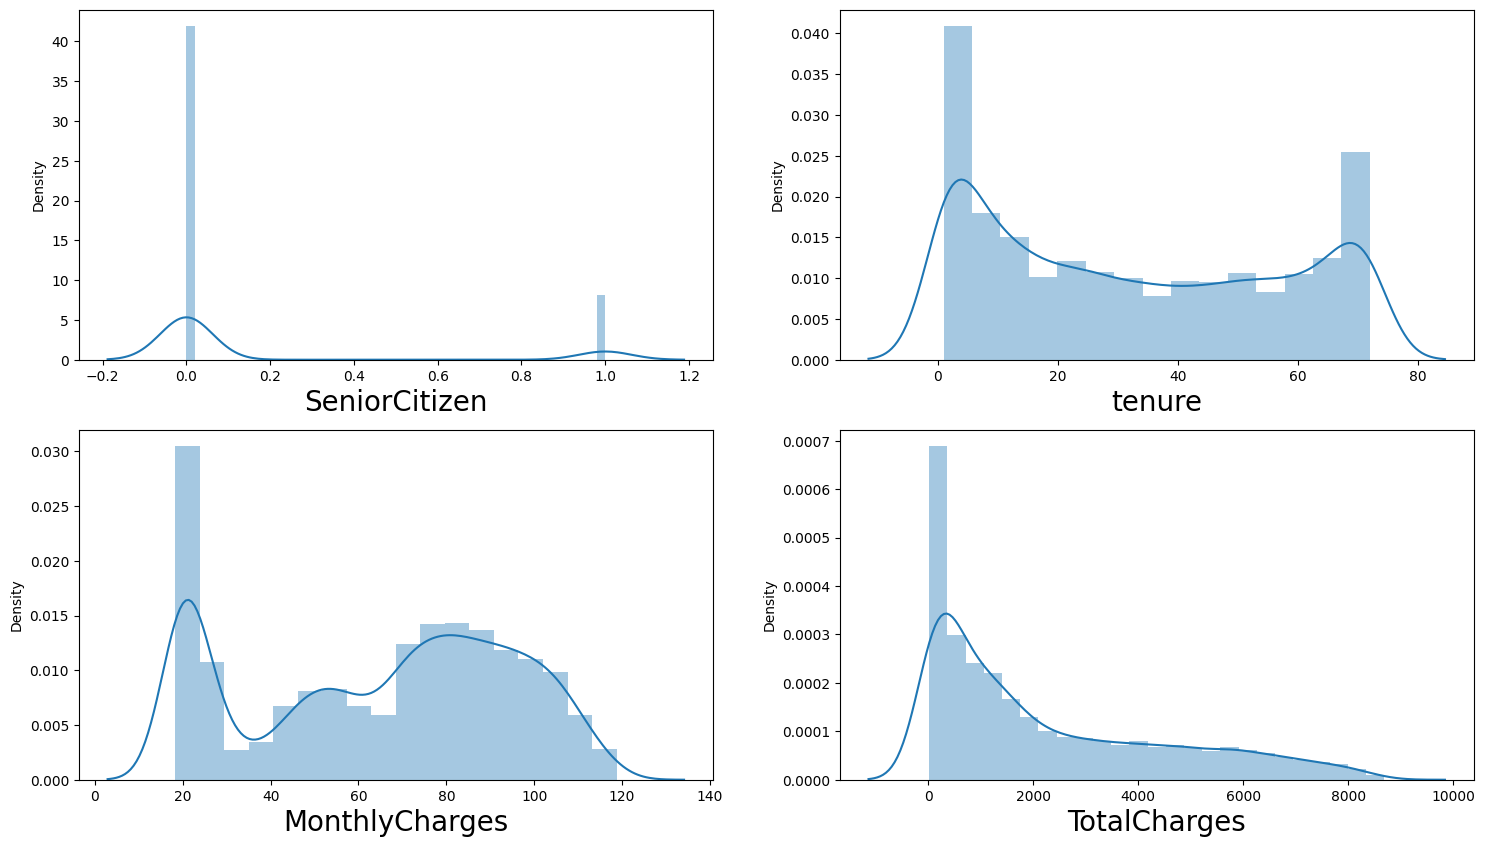

In [75]:
plt.figure(figsize=(18,10),facecolor="white")
plotnumber=1

for column in num_features:
    if plotnumber:
        ax=plt.subplot(2,2,plotnumber)
        sns.distplot(X[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [76]:
X.skew()

gender             -0.018776
SeniorCitizen       1.831103
Partner             0.070024
Dependents          0.880908
tenure              0.237731
MultipleLines       0.118623
InternetService     0.205704
OnlineSecurity      0.418619
OnlineBackup        0.184089
DeviceProtection    0.188013
TechSupport         0.403966
StreamingTV         0.029366
StreamingMovies     0.013851
Contract            0.635149
PaperlessBilling   -0.377503
PaymentMethod      -0.169388
MonthlyCharges     -0.222103
TotalCharges        0.961642
dtype: float64

In [77]:
skew=["TotalCharges"]
skewness=PowerTransformer(method="yeo-johnson")
X[skew]=skewness.fit_transform(X[skew].values)

In [78]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [79]:
oversample=SMOTE()
X,y=oversample.fit_resample(X,y)

In [80]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.850000,-1.810069
1,1,0,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.950000,0.254257
2,1,0,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.850000,-1.386091
3,1,0,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.300000,0.233220
4,0,0,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.700000,-1.248808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10321,0,0,1,0,7,2,1,0,0,0,0,0,2,0,1,2,84.852717,-0.412347
10322,0,0,0,0,51,2,1,1,0,0,0,0,0,0,0,1,77.707255,0.882167
10323,0,0,0,0,19,2,1,0,0,0,0,0,2,0,1,1,83.979735,0.075155
10324,0,1,1,0,32,2,1,0,0,0,0,1,0,0,0,1,85.764323,0.535407


In [81]:
y.value_counts()

Churn
0    5163
1    5163
Name: count, dtype: int64

In [82]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((8260, 18), (2066, 18))

In [84]:
def evaluate_model(true,predicted):
    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)
    return accuracy,precision,recall,f1

In [85]:
models={
    "Logestic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boosting":GradientBoostingClassifier(),
    "AdaBoost":AdaBoostClassifier(),
    "XGBoost":XGBClassifier(),
    "CatBoost":CatBoostClassifier(verbose=False),
    "KNN":KNeighborsClassifier(),
    "SVM":SVC()

}

model_list=[]
accuracy_list=[]
precision_list = []
recall_list = []
f1_list = []

for i in range(len(list(models))):
    model=list(models.values())[i]
    model_name=list(models.keys())[i]
    model.fit(X_train,y_train) #train model 

    #Make Prediction
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)


    # Evaluate Train and Test dataset
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(y_train,y_train_pred)

    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(
        y_test,
        y_test_pred
    )

    model_list.append(model_name)
    accuracy_list.append(test_accuracy)
    precision_list.append(test_precision)
    recall_list.append(test_recall)
    f1_list.append(test_f1)

    print("="*60)
    print(model_name)
    print("="*60)

    print("Training Performance")
    print(f"Accuracy : {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1 Score : {train_f1:.4f}")

    print("-"*60)

    print("Testing Performance")
    print(f"Accuracy : {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_test_pred))
    print()


Logestic Regression
Training Performance
Accuracy : 0.7913
Precision: 0.7710
Recall   : 0.8292
F1 Score : 0.7991
------------------------------------------------------------
Testing Performance
Accuracy : 0.7899
Precision: 0.7712
Recall   : 0.8222
F1 Score : 0.7959

Confusion Matrix
[[786 251]
 [183 846]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      1037
           1       0.77      0.82      0.80      1029

    accuracy                           0.79      2066
   macro avg       0.79      0.79      0.79      2066
weighted avg       0.79      0.79      0.79      2066


Decision Tree
Training Performance
Accuracy : 0.9990
Precision: 0.9995
Recall   : 0.9985
F1 Score : 0.9990
------------------------------------------------------------
Testing Performance
Accuracy : 0.8069
Precision: 0.7928
Recall   : 0.8290
F1 Score : 0.8105

Confusion Matrix
[[814 223]
 [176 853]]

Classification Report
              prec

In [86]:
results = pd.DataFrame({
    "Model": model_list,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1 Score": f1_list
})

results = results.sort_values(by="F1 Score", ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.852372,0.837058,0.873664,0.854969
5,XGBoost,0.844627,0.830841,0.863946,0.847070
6,CatBoost,0.837851,0.822491,0.860058,0.840855
8,SVM,0.820910,0.792889,0.866861,0.828227
3,Gradient Boosting,0.818974,0.794779,0.858115,0.825234
4,AdaBoost,0.802517,0.772130,0.856171,0.811982
1,Decision Tree,0.806873,0.792751,0.828960,0.810451
7,KNN,0.797193,0.762027,0.862002,0.808938
0,Logestic Regression,0.789932,0.771194,0.822157,0.795861
